<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Projetos/Autoencoder/Autoencoder_base_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder com CNN - base cifar10

In [ ]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import InputLayer, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Verificar as dimensões dos dados
print(f"Shape dos dados de treino: {X_train.shape}")
print(f"Shape dos labels de treino: {y_train.shape}")
print(f"Shape dos dados de teste: {X_test.shape}")
print(f"Shape dos labels de teste: {y_test.shape}")

Shape dos dados de treino: (50000, 32, 32, 3)
Shape dos labels de treino: (50000, 1)
Shape dos dados de teste: (10000, 32, 32, 3)
Shape dos labels de teste: (10000, 1)


In [ ]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

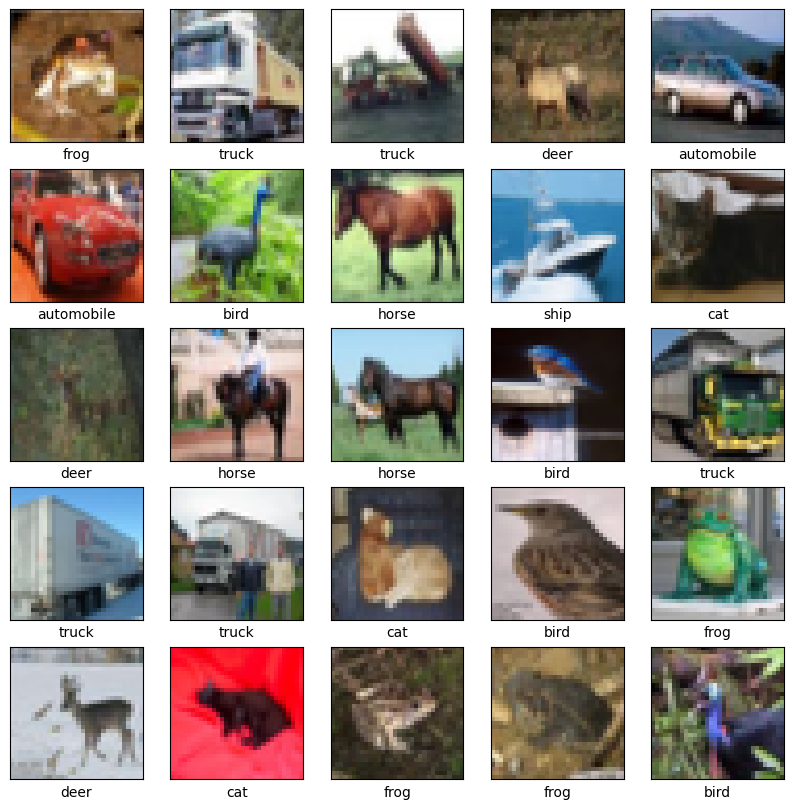

In [ ]:
plt.figure(figsize = (10, 10))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i])
  plt.xlabel(class_names[y_train[i]])
plt.show()

In [ ]:
autoencoder = Sequential()

In [ ]:
autoencoder = Sequential()

# Codificador
autoencoder.add(InputLayer(shape=(32, 32, 3)))
autoencoder.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=(2,2)))  # 16x16x64

autoencoder.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=(2,2)))  # 8x8x128

autoencoder.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=(2,2)))  # 4x4x256

autoencoder.add(Flatten())  # 4*4*256 = 4096

# Decodificador
autoencoder.add(Reshape((4, 4, 256)))
autoencoder.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D(size=(2,2)))  # 8x8x128

autoencoder.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D(size=(2,2)))  # 16x16x64

autoencoder.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D(size=(2,2)))  # 32x32x32

autoencoder.add(Conv2D(filters=3, kernel_size=(3,3), activation='sigmoid', padding='same'))

In [ ]:
autoencoder.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])
autoencoder.fit(X_train, X_train, epochs = 10, batch_size = 256, validation_data = (X_test, X_test))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 537s 3s/step - accuracy: 0.5297 - loss: 0.6341 - val_accuracy: 0.6925 - val_loss: 0.5813
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.7160 - loss: 0.5775 - val_accuracy: 0.7524 - val_loss: 0.5736
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.7480 - loss: 0.5726 - val_accuracy: 0.7684 - val_loss: 0.5706
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 535s 3s/step - accuracy: 0.7614 - loss: 0.5704 - val_accuracy: 0.7746 - val_loss: 0.5692
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.7637 - loss: 0.5680 - val_accuracy: 0.7771 - val_loss: 0.5668
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 531s 3s/step - accuracy: 0.7683 - loss: 0.5656 - val_accuracy: 0.7643 - val_loss: 0.5661
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.7735 - loss: 0.5644 - val_accuracy: 0.7816 - val_loss: 0.5638
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 543s 3s/step - accuracy: 0.7738 - loss: 0.5636 - val_accu

In [ ]:
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,276,939 (8.69 MB)

 Trainable params: 758,979 (2.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,517,960 (5.79 MB)

In [ ]:
encoder = Model(inputs = autoencoder.get_layer("conv2d_10").input, outputs = autoencoder.get_layer("flatten_2").output)

In [ ]:
imagens_codificadas = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step


In [ ]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step


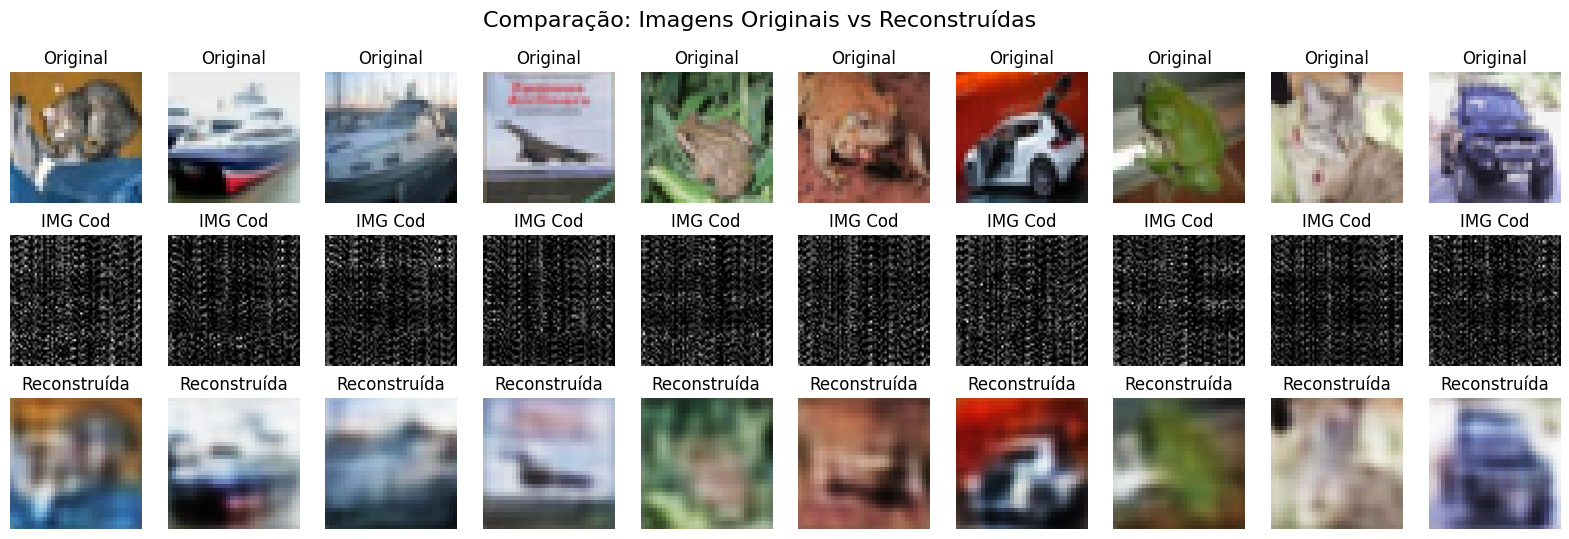

In [ ]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Imagem original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i])  # CIFAR-10 já é colorido (32x32x3)
    plt.title("Original")
    plt.axis('off')

    # imagem codificada
    ax = plt.subplot(3, n, i + 1 + n)
    img_temp = imagens_codificadas[i]
    plt.imshow(img_temp.reshape(64, 64), cmap='gray')
    plt.title("IMG Cod")
    plt.axis("off")

    # Imagem reconstruída
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i])  # Formato já é 32x32x3
    plt.title("Reconstruída")
    plt.axis('off')

plt.suptitle('Comparação: Imagens Originais vs Reconstruídas', fontsize=16)
plt.show()